# QUY HOẠCH TUYẾN TÍNH TRONG CHƯƠNG TRÌNH THPT (GDPT 2018)
### Lớp 10 (Chương II – Hệ bất phương trình bậc nhất hai ẩn) và Chuyên đề học tập Toán 12 — giải bằng phương pháp hình học trên Google Colab

Notebook giải các bài toán quy hoạch tuyến tính hai ẩn trong sách *Kết nối tri thức với cuộc sống* theo đúng trình tự lời giải ở phổ thông, **in từng bước** như bài làm của học sinh:

1. Lập mô hình (đặt ẩn, hệ ràng buộc, hàm mục tiêu $F$);
2. Tìm tọa độ các đỉnh của miền nghiệm (tính **chính xác** bằng phân số);
3. Nhận xét miền nghiệm: bị chặn hay không bị chặn;
4. Tính $F$ tại các đỉnh và kết luận (kể cả trường hợp **vô số nghiệm** và yêu cầu **nghiệm nguyên**);
5. Vẽ miền nghiệm và đường mức tối ưu;
6. **Kiểm chứng** bằng `scipy.optimize.linprog`;
7. Xuất **lệnh GeoGebra** để dựng lại hình trong GeoGebra Classic (có thanh trượt cho đường mức).

## Cách dùng
1. Chạy **Mục 1 — Bộ giải** trước (Runtime ▸ Run all).
2. Chạy ô code của bài cần xem. Muốn giải bài mới: dùng **Mục 5 — Mẫu**.
3. Để dựng hình trong GeoGebra: mở [geogebra.org/classic](https://www.geogebra.org/classic), dán **từng dòng** trong phần *LỆNH GEOGEBRA* vào ô **Nhập**.

## Mục lục
- [1. Bộ giải (chạy trước)](#engine)
- [2. Lớp 10](#lop10): [Bài 2.6](#b26) · [Bài 2.15](#b215) · [Bài 2.16](#b216)
- [3. Lớp 12 – Chuyên đề học tập](#lop12): [Bài 2.1](#b21) · [Bài 2.2](#b22) · [Bài 2.3](#b23) · [Bài 2.4](#b24) · [Bài 2.5](#b25)
- [4. Đề thi tốt nghiệp THPT 2025](#thpt2025)
- [5. Mẫu: giải bài toán của bạn](#mau)

## Bảng đáp án

| Bài | Loại | Phương án tối ưu | Giá trị tối ưu | Điểm đáng chú ý |
|---|---|---|---|---|
| 2.6 (L10) | min | 0,3 kg bò; 1,1 kg lợn | 251 nghìn đồng | Có ràng buộc chặn trên $x \le 1{,}6$; $y \le 1{,}1$ |
| 2.15 (L10) | max | 750 tr CP; 250 tr NH; 200 tr DN | 96,5 triệu đồng | Bài 3 ẩn quy về 2 ẩn; hàm mục tiêu có hằng số |
| 2.16 (L10) | max | 200 s phát thanh; 360 s truyền hình | hiệu quả 3 080 | |
| 2.1 (L12) | min | 0 bàn chữ nhật; 25 bàn tròn | 7 500 nghìn đồng | Yêu cầu **nghiệm nguyên** |
| 2.2 (L12) | max | mọi điểm trên đoạn nối (300; 200) và (150; 300) | 480 triệu đồng | **Vô số phương án tối ưu** |
| 2.3 (L12) | max | 700 đơn vị X; 400 đơn vị Y | 34 800 000 đồng | |
| 2.4 (L12) | min | 50 đơn vị $F_1$; 300 đơn vị $F_2$ | 276 000 đồng | **Miền nghiệm không bị chặn** |
| 2.5 (L12) | min | 5 g S1; 1 g S2 | 4 560 đồng | Miền không bị chặn, 4 ràng buộc |
| TN THPT 2025 | max | 30 thực đơn 1; 35 thực đơn 2 | 2 650 nghìn đồng | Nghiệm nguyên |

> 📝 Sau khi dùng thử, xin góp ý qua [Phiếu đánh giá sản phẩm](https://docs.google.com/forms/d/e/1FAIpQLScNqxvL5WIb8PxsOMvBbOrmmGTwV56bMyRV8-Nb_2Zvj225iw/viewform) (khoảng 5 phút).

<a name="engine"></a>

## 1. Bộ giải *(chạy ô này trước tiên)*

Hàm chính: **`giai(ten, muc_tieu, loai, rang_buoc, ...)`**; hàm phụ: **`tuong_tac(bt)`** (thanh trượt đường mức), **`lenh_geogebra(bt)`**, **`ve_hinh(bt)`**.

In [ ]:
# ======================================================================
# BỘ GIẢI BÀI TOÁN QUY HOẠCH TUYẾN TÍNH HAI ẨN BẰNG PHƯƠNG PHÁP HÌNH HỌC
# - Tính đỉnh miền nghiệm CHÍNH XÁC (phân số), in từng bước như lời giải tay
# - Nhận biết: miền nghiệm không bị chặn, bài toán không có GTLN/GTNN,
#   vô số nghiệm tối ưu (đường mức song song một cạnh), yêu cầu nghiệm nguyên
# - Vẽ miền nghiệm + đường mức tối ưu; thanh trượt tương tác (Colab)
# - Xuất danh sách LỆNH GEOGEBRA để dán vào GeoGebra Classic
# - Kiểm chứng kết quả bằng scipy.optimize.linprog
# Gọi:  bt = giai(ten, muc_tieu, loai, rang_buoc, ...)
# ======================================================================
from fractions import Fraction as Fr
from itertools import combinations
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

def _fr(v):
    return v if isinstance(v, Fr) else Fr(str(v))

def so(v):
    """In số đẹp: số nguyên, số thập phân hữu hạn, hoặc phân số."""
    v = Fr(v)
    if v.denominator == 1:
        return f"{v.numerator:,}".replace(",", " ")
    d = v.denominator
    while d % 2 == 0: d //= 2
    while d % 5 == 0: d //= 5
    if d == 1:
        s = f"{float(v):.6f}".rstrip("0").rstrip(".")
        return s.replace(".", ",")
    return f"{v.numerator}/{v.denominator}"

def _bt(a, b, bx="x", by="y", c0=0):
    """Viết biểu thức a*x + b*y (+ c0)."""
    parts = []
    for coef, name in ((a, bx), (b, by)):
        coef = Fr(coef)
        if coef == 0: continue
        sign = "-" if coef < 0 else "+"
        mag = abs(coef)
        t = name if mag == 1 else f"{so(mag)}{name}"
        parts.append((sign, t))
    if Fr(c0) != 0:
        parts.append(("-" if Fr(c0) < 0 else "+", so(abs(Fr(c0)))))
    if not parts: return "0"
    s = ("-" if parts[0][0] == "-" else "") + parts[0][1]
    for sg, t in parts[1:]:
        s += f" {sg} {t}"
    return s

DAU = {"<=": "≤", ">=": "≥", "=": "="}

class BaiToan:
    pass

def _thoa(rb, P, eps=0):
    a, b, d, c = rb
    v = a * P[0] + b * P[1]
    if d == "<=": return v <= c
    if d == ">=": return v >= c
    return v == c

def _giao(r1, r2):
    a1, b1, _, c1 = r1; a2, b2, _, c2 = r2
    det = a1 * b2 - a2 * b1
    if det == 0: return None
    return ((c1 * b2 - c2 * b1) / det, (a1 * c2 - a2 * c1) / det)

def _dinh(rbs):
    pts = []
    for r1, r2 in combinations(rbs, 2):
        P = _giao(r1, r2)
        if P is not None and all(_thoa(r, P) for r in rbs) and P not in pts:
            pts.append(P)
    return pts

def _sap_xep(pts):
    if len(pts) < 3: return pts
    cx = sum(float(p[0]) for p in pts) / len(pts)
    cy = sum(float(p[1]) for p in pts) / len(pts)
    return sorted(pts, key=lambda p: math.atan2(float(p[1]) - cy, float(p[0]) - cx))

def giai(ten, muc_tieu, loai, rang_buoc, bien=("x", "y"), hang_so=0,
         so_nguyen=False, don_vi="", khung=None, ve=True, geogebra=True):
    """
    ten       : tên bài
    muc_tieu  : (p, q)  ->  F = p*x + q*y + hang_so
    loai      : 'max' hoặc 'min'
    rang_buoc : list các (a, b, dau, c) nghĩa là a*x + b*y dau c ; dau in '<=', '>=', '='
                (điều kiện x >= 0, y >= 0 được thêm tự động)
    so_nguyen : True nếu x, y phải là số nguyên (số bàn, số sản phẩm ...)
    khung     : (xmax, ymax) khung vẽ; bỏ trống để tự chọn
    """
    bx, by = bien
    p, q = _fr(muc_tieu[0]), _fr(muc_tieu[1]); c0 = _fr(hang_so)
    rbs = [(_fr(a), _fr(b), d, _fr(c)) for (a, b, d, c) in rang_buoc]
    rbs_day_du = rbs + [(Fr(1), Fr(0), ">=", Fr(0)), (Fr(0), Fr(1), ">=", Fr(0))]
    F = lambda P: p * P[0] + q * P[1] + c0
    tt = "LỚN NHẤT" if loai == "max" else "NHỎ NHẤT"
    print("=" * 74); print(ten.upper()); print("=" * 74)

    # ---- Bước 1: mô hình
    print("BƯỚC 1 – MÔ HÌNH TOÁN HỌC")
    print(f"  Tìm giá trị {tt.lower()} của  F = {_bt(p, q, bx, by, c0)}" + (f"   ({don_vi})" if don_vi else ""))
    print("  với hệ ràng buộc:")
    for (a, b, d, c) in rbs:
        print(f"      {_bt(a, b, bx, by)} {DAU[d]} {so(c)}")
    print(f"      {bx} ≥ 0,  {by} ≥ 0" + (f";  {bx}, {by} nguyên" if so_nguyen else ""))

    # ---- Bước 2: đỉnh
    pts = _sap_xep(_dinh(rbs_day_du))
    print("\nBƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)")
    if not pts:
        print("  Hệ bất phương trình VÔ NGHIỆM (miền nghiệm rỗng)  =>  bài toán không có phương án.")
        return None
    ten_dinh = [chr(65 + i) for i in range(len(pts))]
    for n, P in zip(ten_dinh, pts):
        print(f"  {n}({so(P[0])}; {so(P[1])})")

    # ---- miền có bị chặn không?
    A_ub, b_ub, A_eq, b_eq = [], [], [], []
    for (a, b, d, c) in rbs:
        if d == "<=": A_ub.append([float(a), float(b)]); b_ub.append(float(c))
        elif d == ">=": A_ub.append([-float(a), -float(b)]); b_ub.append(-float(c))
        else: A_eq.append([float(a), float(b)]); b_eq.append(float(c))
    kw = dict(A_ub=A_ub or None, b_ub=b_ub or None, A_eq=A_eq or None, b_eq=b_eq or None,
              bounds=[(0, None), (0, None)], method="highs")
    bi_chan = linprog([-1, -1], **kw).status != 3
    sgn = -1 if loai == "max" else 1
    res = linprog([sgn * float(p), sgn * float(q)], **kw)
    co_toi_uu = res.status == 0

    print("\nBƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM")
    if bi_chan:
        print(f"  Miền nghiệm là đa giác {''.join(ten_dinh)} (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.")
    else:
        print(f"  Miền nghiệm KHÔNG BỊ CHẶN (kéo dài ra vô tận), có các đỉnh {', '.join(ten_dinh)}.")
        if co_toi_uu:
            print(f"  F vẫn có giá trị {tt.lower()}: khi đường mức {_bt(p, q, bx, by)} = k dịch chuyển theo hướng làm F")
            print(f"  {'tăng' if loai == 'max' else 'giảm'}, nó rời khỏi miền nghiệm tại một đỉnh  =>  chỉ cần so sánh F tại các đỉnh.")
        else:
            print(f"  F KHÔNG có giá trị {tt.lower()}: có thể đi ra xa vô tận trong miền nghiệm mà F")
            print(f"  {'tăng' if loai == 'max' else 'giảm'} mãi  =>  bài toán không có phương án tối ưu.")

    # ---- Bước 4: bảng giá trị
    print(f"\nBƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH")
    vals = [F(P) for P in pts]
    for n, P, v in zip(ten_dinh, pts, vals):
        ct = f"{so(p)}·{so(P[0])} + {so(q)}·{so(P[1])}".replace("+ -", "- ")
        if c0 > 0: ct += f" + {so(c0)}"
        if c0 < 0: ct += f" - {so(-c0)}"
        print(f"  F({n}) = {ct} = {so(v)}")
    bt = BaiToan()
    bt.__dict__.update(ten=ten, p=p, q=q, c0=c0, loai=loai, rbs=rbs, bien=bien, pts=pts, ten_dinh=ten_dinh,
                       bi_chan=bi_chan, khung=khung, don_vi=don_vi, so_nguyen=so_nguyen)
    if not co_toi_uu:
        bt.opt = None; bt.fopt = None
        print(f"\nKẾT LUẬN: F không có giá trị {tt.lower()} trên miền nghiệm.")
        if ve: ve_hinh(bt)
        return bt
    best = max(vals) if loai == "max" else min(vals)
    idx = [i for i, v in enumerate(vals) if v == best]
    print("\nBƯỚC 5 – KẾT LUẬN")
    if len(idx) == 1:
        P = pts[idx[0]]
        print(f"  F đạt giá trị {tt.lower()} bằng {so(best)} tại đỉnh {ten_dinh[idx[0]]}: {bx} = {so(P[0])}, {by} = {so(P[1])}.")
    else:
        ds = " và ".join(f"{ten_dinh[i]}({so(pts[i][0])}; {so(pts[i][1])})" for i in idx)
        print(f"  F đạt giá trị {tt.lower()} bằng {so(best)} tại HAI đỉnh {ds}.")
        print(f"  Đường mức song song với cạnh nối hai đỉnh này  =>  MỌI điểm trên cạnh đó đều là phương án tối ưu")
        print(f"  (bài toán có vô số phương án tối ưu).")
    opt = pts[idx[0]]; fopt = best

    # ---- nghiệm nguyên
    if so_nguyen:
        nguyen = [i for i in idx if pts[i][0].denominator == 1 and pts[i][1].denominator == 1]
        if nguyen:
            opt = pts[nguyen[0]]
            print(f"  Phương án tối ưu đã là số nguyên  =>  thoả yêu cầu nghiệm nguyên.")
        else:
            print("  Phương án tối ưu KHÔNG nguyên  =>  xét các điểm nguyên trong miền nghiệm gần đỉnh tối ưu:")
            xs = [float(P[0]) for P in pts]; ys = [float(P[1]) for P in pts]
            X = int(max(xs)) + 1; Y = int(max(ys)) + 1
            cand = [(Fr(i), Fr(j)) for i in range(0, X + 1) for j in range(0, Y + 1)
                    if all(_thoa(r, (Fr(i), Fr(j))) for r in rbs)]
            cand.sort(key=lambda P: (-F(P) if loai == "max" else F(P)))
            for P in cand[:3]:
                print(f"     ({so(P[0])}; {so(P[1])})  ->  F = {so(F(P))}")
            opt = cand[0]; fopt = F(opt)
            print(f"  => Phương án nguyên tối ưu: {bx} = {so(opt[0])}, {by} = {so(opt[1])},  F = {so(fopt)}")
    bt.opt = opt; bt.fopt = fopt; bt.idx = idx

    # ---- kiểm chứng
    integ = [1, 1] if so_nguyen else None
    r2 = linprog([sgn * float(p), sgn * float(q)], integrality=integ, **kw)
    f2 = sgn * r2.fun + float(c0)
    ok = abs(f2 - float(fopt)) < 1e-6
    print(f"\nKIỂM CHỨNG (scipy.optimize.linprog): F = {so(Fr(round(f2, 6)).limit_denominator(10**6))}"
          + f"  ->  {'KHỚP ✓' if ok else 'KHÔNG KHỚP ✗'}")
    if geogebra: lenh_geogebra(bt)
    if ve: ve_hinh(bt)
    return bt

MAU = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#17becf"]

def lenh_geogebra(bt, in_ra=True):
    """Sinh danh sách LỆNH GEOGEBRA dựng lại bài toán (miền nghiệm, đường biên, đỉnh,
    hàm mục tiêu, thanh trượt đường mức, điểm P kéo thử, đáp án ẩn/hiện).
    Dán lần lượt từng dòng vào ô Nhập (Input) của GeoGebra Classic."""
    bx, by = bt.bien
    X, Y = _khung(bt)
    L = []
    def c(s): L.append(s)
    conds = [f"{_gge(a, b)} {'<=' if d == '<=' else ('>=' if d == '>=' else '==')} {_gg(cc)}" for (a, b, d, cc) in bt.rbs]
    c("MienNghiem: " + " && ".join(conds + ["x >= 0", "y >= 0"]))
    c('SetColor(MienNghiem, "#6BAED6")'); c("SetFilling(MienNghiem, 0.3)"); c("ShowLabel(MienNghiem, false)"); c("SetLineThickness(MienNghiem, 1)")
    for i, (a, b, d, cc) in enumerate(bt.rbs, 1):
        eq = f"{_gge(a, b)} = {_gg(cc)}"
        c(f"d_{{{i}}}: {eq}")
        c(f'SetCaption(d_{{{i}}}, "d{i}: {_bt(a, b)} = {so(cc)}")'); c(f"SetLabelMode(d_{{{i}}}, 3)")
        c(f'SetColor(d_{{{i}}}, "{MAU[(i - 1) % len(MAU)]}")'); c(f"SetLineThickness(d_{{{i}}}, 4)"); c(f"SetLayer(d_{{{i}}}, 1)")
    for n, P in zip(bt.ten_dinh, bt.pts):
        c(f"{n} = ({_gg(P[0])}, {_gg(P[1])})"); c(f"SetLabelMode({n}, 1)"); c(f'SetColor({n}, "#000000")'); c(f"SetFixed({n}, true)")
    fx = f"{_gge(bt.p, bt.q)}" + (f" + {_gg(bt.c0)}" if bt.c0 > 0 else (f" - {_gg(-bt.c0)}" if bt.c0 < 0 else ""))
    c(f"F(x, y) = {fx}")
    for n in bt.ten_dinh:
        c(f"F_{{{n}}} = F(x({n}), y({n}))")
    vs = [float(bt.p * P[0] + bt.q * P[1]) for P in bt.pts]
    lo, hi = min(vs), max(vs); span = (hi - lo) or abs(hi) or 1
    step = 10 ** math.floor(math.log10(span / 200)) if span > 0 else 1
    lo2 = math.floor((lo - 0.5 * span) / step) * step; hi2 = math.ceil((hi + 0.5 * span) / step) * step
    start = (lo + hi) / 2 if bt.bi_chan else (hi if bt.loai == "min" else lo)
    start = round(start / step) * step
    c(f"k = Slider({lo2:g}, {hi2:g}, {step:g}, 1, 300, false, true, false, false)")
    c(f"SetValue(k, {start:g})"); c('SetCaption(k, "k (giá trị của đường mức)")')
    c(f"DuongMuc: {_gge(bt.p, bt.q)} = k")
    c('SetColor(DuongMuc, "#C51B8A")'); c("SetLineStyle(DuongMuc, 1)"); c("SetLineThickness(DuongMuc, 7)")
    c("ShowLabel(DuongMuc, false)"); c("SetLayer(DuongMuc, 2)")
    poly = _mien_cat(bt, X, Y)
    if len(poly) >= 3:
        c("VungKeo = Polygon({" + ", ".join(f"({float(P[0]):g}, {float(P[1]):g})" for P in poly) + "})")
        c("SetVisibleInView(VungKeo, 1, false)")
        cx = sum(float(P[0]) for P in poly) / len(poly); cy = sum(float(P[1]) for P in poly) / len(poly)
        c("P = PointIn(VungKeo)"); c(f"SetCoords(P, {cx:.4g}, {cy:.4g})"); c('SetColor(P, "#FF7F00")'); c("SetPointSize(P, 6)")
        c("F_{P} = F(x(P), y(P))")
    if bt.so_nguyen:
        xs = int(X); ys = int(Y)
        if (xs + 1) * (ys + 1) <= 2500:
            cond = " && ".join(f"{_gge(a, b).replace('x', 'i').replace('y', 'j')} {'<=' if d == '<=' else ('>=' if d == '>=' else '==')} {_gg(cc)}"
                               for (a, b, d, cc) in bt.rbs)
            c(f"DiemNguyen = Flatten(Sequence(Sequence(If({cond}, (i, j)), i, 0, {xs}), j, 0, {ys}))")
            c('SetColor(DiemNguyen, "#636363")'); c("SetPointSize(DiemNguyen, 2)"); c("ShowLabel(DiemNguyen, false)")
    c('hienDapAn = Checkbox("Hiện đáp án")')
    tt = "lớn nhất" if bt.loai == "max" else "nhỏ nhất"
    if bt.fopt is None:
        ans = f"F không có giá trị {tt}"
    elif len(getattr(bt, "idx", [])) > 1:
        i1, i2 = bt.idx[0], bt.idx[1]
        ans = f"F {tt} = {so(bt.fopt)} trên cả cạnh {bt.ten_dinh[i1]}{bt.ten_dinh[i2]}"
        c(f"CanhToiUu = Segment({bt.ten_dinh[i1]}, {bt.ten_dinh[i2]})"); c('SetColor(CanhToiUu, "#D7301F")')
        c("SetLineThickness(CanhToiUu, 13)"); c("ShowLabel(CanhToiUu, false)"); c("SetConditionToShowObject(CanhToiUu, hienDapAn)")
    else:
        ans = f"F {tt} = {so(bt.fopt)} tại {bx} = {so(bt.opt[0])}, {by} = {so(bt.opt[1])}"
        c(f"ToiUu = ({_gg(bt.opt[0])}, {_gg(bt.opt[1])})"); c('SetColor(ToiUu, "#D7301F")'); c("SetPointStyle(ToiUu, 3)")
        c("SetPointSize(ToiUu, 9)"); c("ShowLabel(ToiUu, false)"); c("SetLayer(ToiUu, 3)"); c("SetConditionToShowObject(ToiUu, hienDapAn)")
    c(f'DapAn = Text("{ans}", ({0.42 * X:.4g}, {1.2 * Y:.4g}))')
    c('SetColor(DapAn, "#D7301F")'); c("SetConditionToShowObject(DapAn, hienDapAn)")
    c(f"ZoomIn({-0.12 * X:.4g}, {-0.08 * Y:.4g}, {1.05 * X:.4g}, {1.28 * Y:.4g})")
    c("SetCoords(k, 40, 30)"); c("SetCoords(hienDapAn, 40, 70)")
    if in_ra:
        print("\nLỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):")
        for s_ in L: print("   " + s_)
        print("   -> Kéo thanh trượt k: đường mức tịnh tiến; đỉnh cuối cùng đường mức chạm miền nghiệm là điểm tối ưu.")
        print("   -> Kéo điểm P trong miền nghiệm để xem F_P thay đổi; tích 'Hiện đáp án' để kiểm tra.")
    return L

def _gge(a, b):
    t = []
    for coef, nm in ((Fr(a), "x"), (Fr(b), "y")):
        if coef == 0: continue
        m = "" if abs(coef) == 1 else _gg(abs(coef)) + "*"
        t.append(("-" if coef < 0 else "+", m + nm))
    s = ("-" if t[0][0] == "-" else "") + t[0][1]
    for sg, x in t[1:]: s += f" {sg} {x}"
    return s

def _gg(v):
    v = Fr(v)
    return str(v.numerator) if v.denominator == 1 else f"{v.numerator}/{v.denominator}"

def _mien_cat(bt, X, Y):
    box = [(Fr(1), Fr(0), "<=", Fr(X)), (Fr(0), Fr(1), "<=", Fr(Y)),
           (Fr(1), Fr(0), ">=", Fr(0)), (Fr(0), Fr(1), ">=", Fr(0))]
    return _sap_xep(_dinh(bt.rbs + box))

def _khung(bt):
    if bt.khung: return bt.khung
    xs = [float(P[0]) for P in bt.pts] + [1]; ys = [float(P[1]) for P in bt.pts] + [1]
    k = 1.25 if bt.bi_chan else 1.6
    return (max(xs) * k, max(ys) * k)

def ve_hinh(bt, k=None, ax=None):
    """Vẽ miền nghiệm, các đỉnh, và đường mức F = k (mặc định k = giá trị tối ưu)."""
    X, Y = _khung(bt); bx, by = bt.bien
    show = ax is None
    if ax is None: fig, ax = plt.subplots(figsize=(8, 6))
    poly = _mien_cat(bt, X, Y)
    if len(poly) >= 3:
        ax.fill([float(P[0]) for P in poly], [float(P[1]) for P in poly], color="#9ecae1", alpha=0.45,
                label="Miền nghiệm" + ("" if bt.bi_chan else " (không bị chặn)"))
    xx = np.linspace(0, X, 400); cols = plt.cm.tab10.colors
    for i, (a, b, d, c) in enumerate(bt.rbs):
        a, b, c = float(a), float(b), float(c); lab = f"{_bt(Fr(a), Fr(b), bx, by)} {DAU[d]} {so(Fr(c))}"
        if b != 0: ax.plot(xx, (c - a * xx) / b, color=cols[i % 10], lw=1.4, label=lab)
        else: ax.axvline(c / a, color=cols[i % 10], lw=1.4, label=lab)
    for n, P in zip(bt.ten_dinh, bt.pts):
        ax.plot(float(P[0]), float(P[1]), "ko", ms=5)
        ax.annotate(f"{n}({so(P[0])}; {so(P[1])})", (float(P[0]), float(P[1])), textcoords="offset points",
                    xytext=(5, 5), fontsize=9, weight="bold")
    kk = float(k) if k is not None else (float(bt.fopt - bt.c0) if bt.fopt is not None else None)
    if kk is not None:
        p, q = float(bt.p), float(bt.q)
        if q != 0: ax.plot(xx, (kk - p * xx) / q, "m--", lw=2, label=f"Đường mức {_bt(bt.p, bt.q, bx, by)} = {so(Fr(kk).limit_denominator(10**6))}")
        else: ax.axvline(kk / p, color="m", ls="--", lw=2)
    if bt.fopt is not None and k is None:
        ax.plot(float(bt.opt[0]), float(bt.opt[1]), "r*", ms=16, label=f"Tối ưu: F = {so(bt.fopt)}")
    ax.set_xlim(0, X); ax.set_ylim(0, Y); ax.set_xlabel(bx); ax.set_ylabel(by)
    ax.grid(True, ls="--", alpha=0.5); ax.legend(fontsize=8, loc="best", framealpha=0.85); ax.set_title(bt.ten, fontsize=11)
    if show: plt.show()

def tuong_tac(bt):
    """Thanh trượt k: đường mức p*x + q*y = k tịnh tiến trên miền nghiệm (chạy trên Colab/Jupyter)."""
    import ipywidgets as widgets
    vs = [float(bt.p * P[0] + bt.q * P[1]) for P in bt.pts]
    lo, hi = min(vs), max(vs); span = (hi - lo) or 1
    def _f(k):
        ve_hinh(bt, k=k)
        print(f"Đường mức: {_bt(bt.p, bt.q, *bt.bien)} = {k:g}   (F = {k + float(bt.c0):g})")
    widgets.interact(_f, k=widgets.FloatSlider(value=(lo + hi) / 2, min=lo - 0.5 * span, max=hi + 0.5 * span,
                                               step=span / 200, description="k", layout=widgets.Layout(width="80%")))

print("Đã nạp bộ giải hình học ✓")

<a name="lop10"></a>

## 2. Lớp 10 — Chương II: Bất phương trình và hệ bất phương trình bậc nhất hai ẩn

<a name="b26"></a>

### Bài 2.6 (Bài 4 – Hệ bất phương trình bậc nhất hai ẩn)

> Một gia đình cần ít nhất 900 đơn vị protein và 400 đơn vị lipid trong thức ăn mỗi ngày. Mỗi kilôgam thịt bò chứa 800 đơn vị protein và 200 đơn vị lipid. Mỗi kilôgam thịt lợn chứa 600 đơn vị protein và 400 đơn vị lipid. Biết rằng gia đình này chỉ mua nhiều nhất là 1,6 kg thịt bò và 1,1 kg thịt lợn; giá 1 kg thịt bò là 250 nghìn đồng; giá 1 kg thịt lợn là 160 nghìn đồng. Giả sử gia đình đó mua *x* kilôgam thịt bò và *y* kilôgam thịt lợn. a) Viết hệ bất phương trình và xác định miền nghiệm; b) Biểu diễn số tiền *F* (nghìn đồng) theo *x*, *y*; c) Tìm số kilôgam thịt mỗi loại cần mua để chi phí ít nhất.

**Lập mô hình.** Protein: $800x + 600y \ge 900$; lipid: $200x + 400y \ge 400$; giới hạn mua: $0 \le x \le 1{,}6$, $0 \le y \le 1{,}1$. Chi phí $F = 250x + 160y$ (nghìn đồng) $\to \min$.

BÀI 2.6 – MUA THỊT BÒ VÀ THỊT LỢN
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị nhỏ nhất của  F = 250x + 160y   (nghìn đồng)
  với hệ ràng buộc:
      800x + 600y ≥ 900
      200x + 400y ≥ 400
      x ≤ 1,6
      y ≤ 1,1
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(0,6; 0,7)
  B(1,6; 0,2)
  C(1,6; 1,1)
  D(0,3; 1,1)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCD (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 250·0,6 + 160·0,7 = 262
  F(B) = 250·1,6 + 160·0,2 = 432
  F(C) = 250·1,6 + 160·1,1 = 576
  F(D) = 250·0,3 + 160·1,1 = 251

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị nhỏ nhất bằng 251 tại đỉnh D: x = 0,3, y = 1,1.

KIỂM CHỨNG (scipy.optimize.linprog): F = 251  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):
   MienNghiem: 800*x + 600*y >= 900 && 200*x + 400*y >= 400 && x <= 8/5 && y <= 11/10 && x >= 0 && y >= 0


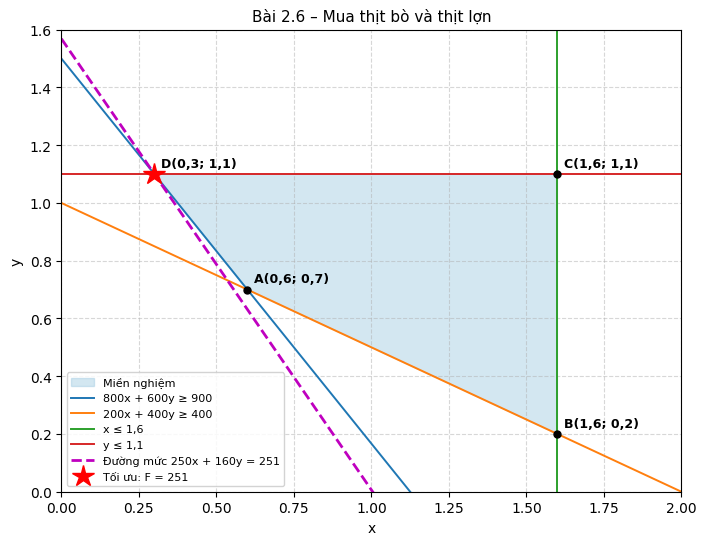

In [2]:
bt26 = giai("Bài 2.6 – Mua thịt bò và thịt lợn", muc_tieu=(250, 160), loai="min",
            rang_buoc=[(800, 600, ">=", 900),   # protein
                       (200, 400, ">=", 400),   # lipid
                       (1, 0, "<=", 1.6),       # tối đa 1,6 kg thịt bò
                       (0, 1, "<=", 1.1)],      # tối đa 1,1 kg thịt lợn
            don_vi="nghìn đồng", khung=(2, 1.6))

**Diễn giải kết quả.** Gia đình nên mua **0,3 kg thịt bò và 1,1 kg thịt lợn**, chi phí ít nhất **251 nghìn đồng**. Vì thịt lợn rẻ hơn tính trên mỗi đơn vị dinh dưỡng, phương án tối ưu dùng hết hạn mức thịt lợn (ràng buộc $y \le 1{,}1$ “chặt”).

<a name="b215"></a>

### Bài 2.15 (Bài tập cuối chương II)

> Bác An đầu tư 1,2 tỉ đồng vào ba loại trái phiếu: trái phiếu chính phủ với lãi suất 7% một năm, trái phiếu ngân hàng với lãi suất 8% một năm và trái phiếu doanh nghiệp rủi ro cao với lãi suất 12% một năm. Vì lí do giảm thuế, bác An muốn số tiền đầu tư trái phiếu chính phủ gấp ít nhất 3 lần số tiền đầu tư trái phiếu ngân hàng. Hơn nữa, để giảm thiểu rủi ro, bác An đầu tư không quá 200 triệu đồng cho trái phiếu doanh nghiệp. Hỏi bác An nên đầu tư mỗi loại trái phiếu bao nhiêu tiền để lợi nhuận thu được sau một năm là lớn nhất?

**Lập mô hình.** Đơn vị: triệu đồng. Gọi $x, y$ là số tiền mua trái phiếu chính phủ, ngân hàng; khi đó trái phiếu doanh nghiệp là $z = 1200 - x - y$. **Quy về hai ẩn:** $x \ge 3y \iff x - 3y \ge 0$; $0 \le z \le 200 \iff 1000 \le x + y \le 1200$. Lợi nhuận $F = 0{,}07x + 0{,}08y + 0{,}12(1200 - x - y) = 144 - 0{,}05x - 0{,}04y \to \max$.

BÀI 2.15 – ĐẦU TƯ TRÁI PHIẾU
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị lớn nhất của  F = -0,05x - 0,04y + 144   (triệu đồng)
  với hệ ràng buộc:
      x - 3y ≥ 0
      x + y ≥ 1 000
      x + y ≤ 1 200
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(1 000; 0)
  B(1 200; 0)
  C(900; 300)
  D(750; 250)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCD (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = -0,05·1 000 - 0,04·0 + 144 = 94
  F(B) = -0,05·1 200 - 0,04·0 + 144 = 84
  F(C) = -0,05·900 - 0,04·300 + 144 = 87
  F(D) = -0,05·750 - 0,04·250 + 144 = 96,5

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị lớn nhất bằng 96,5 tại đỉnh D: x = 750, y = 250.

KIỂM CHỨNG (scipy.optimize.linprog): F = 96,5  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):
   MienNghiem: x - 3*y >= 0 && x + y >= 1000 && x + y <= 1200 && x >= 0 && y >= 0
   

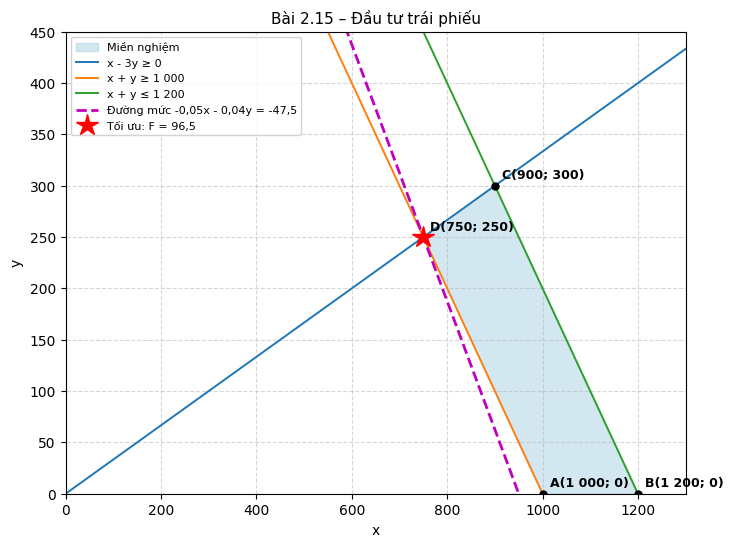

In [3]:
bt215 = giai("Bài 2.15 – Đầu tư trái phiếu", muc_tieu=(-0.05, -0.04), hang_so=144, loai="max",
             rang_buoc=[(1, -3, ">=", 0),        # x >= 3y
                        (1, 1, ">=", 1000),     # z <= 200
                        (1, 1, "<=", 1200)],    # z >= 0
             don_vi="triệu đồng", khung=(1300, 450))

**Diễn giải kết quả.** Bác An nên đầu tư **750 triệu đồng** trái phiếu chính phủ, **250 triệu đồng** trái phiếu ngân hàng và $z = 1200 - 750 - 250 =$ **200 triệu đồng** trái phiếu doanh nghiệp; lợi nhuận lớn nhất **96,5 triệu đồng/năm**. Bài này cho thấy kỹ thuật *khử một ẩn nhờ ràng buộc đẳng thức* để đưa bài toán ba ẩn về hai ẩn.

<a name="b216"></a>

### Bài 2.16 (Bài tập cuối chương II)

> Một công ty dự định chi tối đa 160 triệu đồng cho quảng cáo một sản phẩm mới trong một tháng trên các đài phát thanh và truyền hình. Biết cùng một thời lượng quảng cáo, quảng cáo trên truyền hình có hiệu quả gấp 8 lần trên đài phát thanh. Đài phát thanh chỉ nhận các quảng cáo có tổng thời lượng trong một tháng tối đa là 900 giây với chi phí là 80 nghìn đồng/giây. Đài truyền hình chỉ nhận các quảng cáo có tổng thời lượng trong một tháng tối đa là 360 giây với chi phí là 400 nghìn đồng/giây. Công ty cần đặt thời gian quảng cáo trên các đài phát thanh và truyền hình như thế nào để hiệu quả nhất?

**Lập mô hình.** Gọi $x, y$ (giây) là thời lượng trên đài phát thanh, truyền hình. Ngân sách (nghìn đồng): $80x + 400y \le 160\,000$; $x \le 900$; $y \le 360$. Hiệu quả $F = x + 8y \to \max$.

BÀI 2.16 – PHÂN BỔ THỜI LƯỢNG QUẢNG CÁO
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị lớn nhất của  F = x + 8y   (đơn vị hiệu quả)
  với hệ ràng buộc:
      80x + 400y ≤ 160 000
      x ≤ 900
      y ≤ 360
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(0; 0)
  B(900; 0)
  C(900; 220)
  D(200; 360)
  E(0; 360)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCDE (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 1·0 + 8·0 = 0
  F(B) = 1·900 + 8·0 = 900
  F(C) = 1·900 + 8·220 = 2 660
  F(D) = 1·200 + 8·360 = 3 080
  F(E) = 1·0 + 8·360 = 2 880

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị lớn nhất bằng 3 080 tại đỉnh D: x = 200, y = 360.

KIỂM CHỨNG (scipy.optimize.linprog): F = 3 080  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):
   MienNghiem: 80*x + 400*y <= 160000 && x <= 900 && y <= 360 && x >= 0 && y >= 0
   SetColor(MienNgh

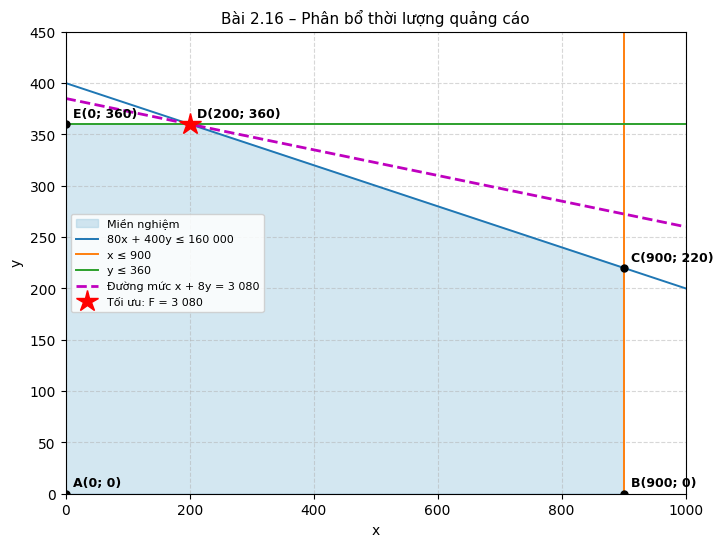

In [4]:
bt216 = giai("Bài 2.16 – Phân bổ thời lượng quảng cáo", muc_tieu=(1, 8), loai="max",
             rang_buoc=[(80, 400, "<=", 160000),   # ngân sách (nghìn đồng)
                        (1, 0, "<=", 900),         # đài phát thanh tối đa 900 s
                        (0, 1, "<=", 360)],        # đài truyền hình tối đa 360 s
             don_vi="đơn vị hiệu quả", khung=(1000, 450))

**Diễn giải kết quả.** Công ty nên quảng cáo **200 giây trên đài phát thanh và 360 giây trên truyền hình** (dùng hết ngân sách 160 triệu và hết thời lượng truyền hình), hiệu quả lớn nhất **3 080 đơn vị**.

**Thử thanh trượt** (chạy trên Colab): kéo *k* để thấy đường mức $x + 8y = k$ tịnh tiến và rời miền nghiệm tại đỉnh tối ưu.

In [ ]:
tuong_tac(bt216)

<a name="lop12"></a>

## 3. Lớp 12 — Chuyên đề học tập: Ứng dụng toán học để giải quyết một số bài toán tối ưu

<a name="b21"></a>

### Bài 2.1

> Một trung tâm tổ chức sự kiện có một phòng tổ chức lễ cưới với hai kiểu bàn ăn: bàn hình chữ nhật ngồi 6 người với giá thuê 200 nghìn đồng và bàn tròn ngồi 10 người với giá thuê 300 nghìn đồng. Anh Nam muốn thuê phòng để tổ chức đám cưới với 250 khách mời. Căn phòng chỉ chứa được tối đa 35 bàn các loại và chỉ có 15 bàn hình chữ nhật. Hỏi anh Nam phải thuê mỗi loại bàn bao nhiêu để giảm thiểu tối đa chi phí mà vẫn đáp ứng được các yêu cầu trên.

**Lập mô hình.** Gọi $x, y$ là số bàn chữ nhật, bàn tròn ($x, y$ **nguyên**). Đủ chỗ: $6x + 10y \ge 250$; sức chứa: $x + y \le 35$; $x \le 15$. Chi phí $F = 200x + 300y$ (nghìn đồng) $\to \min$.

BÀI 2.1 – THUÊ BÀN TIỆC CƯỚI
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị nhỏ nhất của  F = 200x + 300y   (nghìn đồng)
  với hệ ràng buộc:
      6x + 10y ≥ 250
      x + y ≤ 35
      x ≤ 15
      x ≥ 0,  y ≥ 0;  x, y nguyên

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(15; 16)
  B(15; 20)
  C(0; 35)
  D(0; 25)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCD (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 200·15 + 300·16 = 7 800
  F(B) = 200·15 + 300·20 = 9 000
  F(C) = 200·0 + 300·35 = 10 500
  F(D) = 200·0 + 300·25 = 7 500

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị nhỏ nhất bằng 7 500 tại đỉnh D: x = 0, y = 25.
  Phương án tối ưu đã là số nguyên  =>  thoả yêu cầu nghiệm nguyên.

KIỂM CHỨNG (scipy.optimize.linprog): F = 7 500  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):
   MienNghiem: 6*x + 10*y >= 250 && x + y <= 35 && x <= 15 && x 

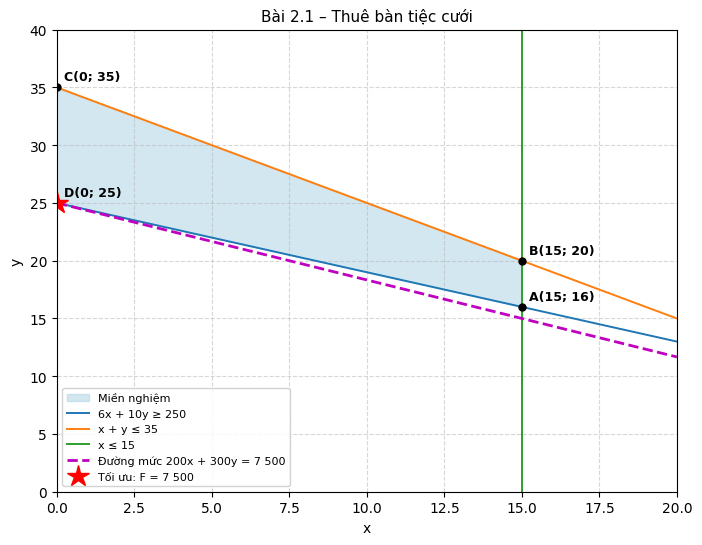

In [6]:
bt21 = giai("Bài 2.1 – Thuê bàn tiệc cưới", muc_tieu=(200, 300), loai="min",
            rang_buoc=[(6, 10, ">=", 250),   # đủ chỗ cho 250 khách
                       (1, 1, "<=", 35),     # tối đa 35 bàn
                       (1, 0, "<=", 15)],    # chỉ có 15 bàn chữ nhật
            so_nguyen=True, don_vi="nghìn đồng", khung=(20, 40))

**Diễn giải kết quả.** Anh Nam nên thuê **25 bàn tròn và không thuê bàn chữ nhật**, chi phí **7 500 nghìn đồng (7,5 triệu đồng)**. Tính trên mỗi chỗ ngồi, bàn tròn rẻ hơn (30 nghìn/chỗ so với khoảng 33,3 nghìn/chỗ). Ở bài này đỉnh tối ưu đã là số nguyên; nếu không, bộ giải sẽ tự xét các điểm nguyên lân cận.

<a name="b22"></a>

### Bài 2.2

> Một cơ sở sản xuất hai loại sữa chua X và Y. Để sản xuất một đơn vị sữa chua X cần 2 kg dâu tây, 2 kg sữa, 0 kg đường; một đơn vị sữa chua Y cần 3 kg dâu tây, 1 kg sữa, 1 kg đường. Nguồn nguyên liệu dự trữ dâu tây, sữa và đường lần lượt là 1,2 tấn; 0,8 tấn và 0,3 tấn. Giá bán mỗi đơn vị sữa chua X và Y lần lượt là 800 nghìn đồng và 1,2 triệu đồng. Cơ sở sản xuất cần sản xuất bao nhiêu đơn vị sữa chua X và Y để lợi nhuận thu được là lớn nhất?

**Lập mô hình.** Gọi $x, y$ là số đơn vị X, Y. Dâu tây: $2x + 3y \le 1200$; sữa: $2x + y \le 800$; đường: $y \le 300$ (đổi tấn ra kg). $F = 800x + 1200y$ (nghìn đồng) $\to \max$.

BÀI 2.2 – SẢN XUẤT SỮA CHUA
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị lớn nhất của  F = 800x + 1 200y   (nghìn đồng)
  với hệ ràng buộc:
      2x + 3y ≤ 1 200
      2x + y ≤ 800
      y ≤ 300
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(0; 0)
  B(400; 0)
  C(300; 200)
  D(150; 300)
  E(0; 300)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCDE (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 800·0 + 1 200·0 = 0
  F(B) = 800·400 + 1 200·0 = 320 000
  F(C) = 800·300 + 1 200·200 = 480 000
  F(D) = 800·150 + 1 200·300 = 480 000
  F(E) = 800·0 + 1 200·300 = 360 000

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị lớn nhất bằng 480 000 tại HAI đỉnh C(300; 200) và D(150; 300).
  Đường mức song song với cạnh nối hai đỉnh này  =>  MỌI điểm trên cạnh đó đều là phương án tối ưu
  (bài toán có vô số phương án tối ưu).

KIỂM CHỨNG (scipy.optimize.linprog): F = 480 000  ->  KHỚP ✓

LỆNH GEOGEBR

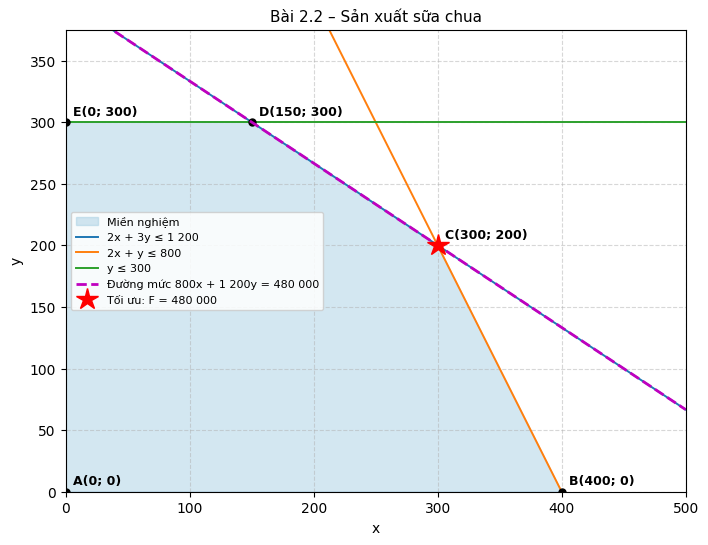

In [7]:
bt22 = giai("Bài 2.2 – Sản xuất sữa chua", muc_tieu=(800, 1200), loai="max",
            rang_buoc=[(2, 3, "<=", 1200),   # dâu tây (kg)
                       (2, 1, "<=", 800),    # sữa (kg)
                       (0, 1, "<=", 300)],   # đường (kg)
            don_vi="nghìn đồng")

**Diễn giải kết quả.** Giá trị lớn nhất **480 000 nghìn đồng (480 triệu đồng)** đạt tại **hai đỉnh** $(300;\,200)$ và $(150;\,300)$. Nguyên nhân: $F = 800x + 1200y = 400(2x + 3y)$ tỉ lệ với vế trái ràng buộc dâu tây, nên đường mức **song song** với cạnh $2x + 3y = 1200$. Mọi phương án trên đoạn nối hai đỉnh (ví dụ $x = 210,\ y = 260$) đều tối ưu — một tình huống hay để thảo luận với học sinh vì sách giáo khoa thường chỉ nêu một đáp án.

<a name="b23"></a>

### Bài 2.3

> Một nhà máy hoá chất sản xuất hai hợp chất X và Y. Khi sản xuất một đơn vị hợp chất X sẽ có 2 dm³ khí CO và 6 dm³ khí SO₂ phát tán ra môi trường. Khi sản xuất một đơn vị hợp chất Y sẽ có 4 dm³ khí CO và 3 dm³ khí SO₂ phát tán ra môi trường. Các yêu cầu về khí thải chỉ cho phép nhà máy phát thải ra môi trường mỗi tuần không quá 3 000 dm³ khí CO và không quá 5 400 dm³ khí SO₂. Nhà máy có thể bán hết tất cả các đơn vị hợp chất X và Y sản xuất ra với giá 36 000 đồng một đơn vị hợp chất X và 24 000 đồng một đơn vị hợp chất Y. Xác định số đơn vị hợp chất X và Y mỗi loại cần sản xuất trong một tuần để thu được lợi nhuận cao nhất mà vẫn đảm bảo các yêu cầu về khí thải môi trường.

**Lập mô hình.** Gọi $x, y$ là số đơn vị X, Y mỗi tuần. CO: $2x + 4y \le 3000$; SO₂: $6x + 3y \le 5400$. $F = 36\,000x + 24\,000y$ (đồng) $\to \max$.

BÀI 2.3 – SẢN XUẤT HỢP CHẤT VỚI HẠN MỨC KHÍ THẢI
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị lớn nhất của  F = 36 000x + 24 000y   (đồng)
  với hệ ràng buộc:
      2x + 4y ≤ 3 000
      6x + 3y ≤ 5 400
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(0; 0)
  B(900; 0)
  C(700; 400)
  D(0; 750)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCD (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 36 000·0 + 24 000·0 = 0
  F(B) = 36 000·900 + 24 000·0 = 32 400 000
  F(C) = 36 000·700 + 24 000·400 = 34 800 000
  F(D) = 36 000·0 + 24 000·750 = 18 000 000

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị lớn nhất bằng 34 800 000 tại đỉnh C: x = 700, y = 400.

KIỂM CHỨNG (scipy.optimize.linprog): F = 34 800 000  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):
   MienNghiem: 2*x + 4*y <= 3000 && 6*x + 3*y <= 5400 && x >= 0 && y >= 0
   SetCo

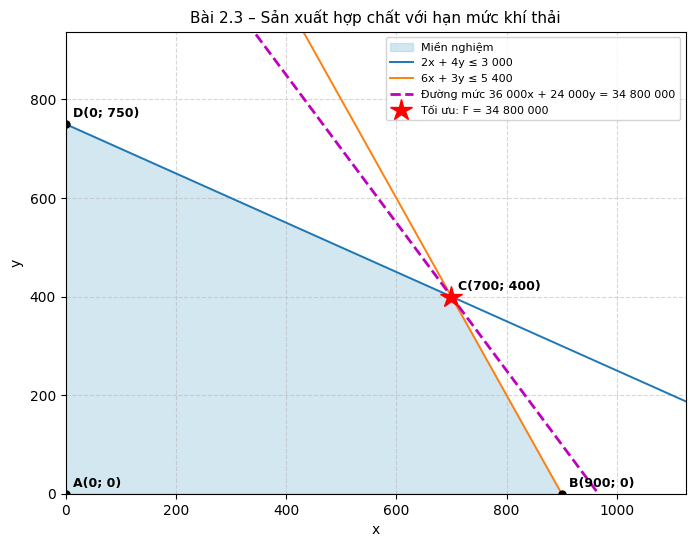

In [8]:
bt23 = giai("Bài 2.3 – Sản xuất hợp chất với hạn mức khí thải", muc_tieu=(36000, 24000), loai="max",
            rang_buoc=[(2, 4, "<=", 3000),   # khí CO
                       (6, 3, "<=", 5400)],  # khí SO2
            don_vi="đồng")

**Diễn giải kết quả.** Nhà máy nên sản xuất **700 đơn vị X và 400 đơn vị Y** mỗi tuần, thu **34 800 000 đồng**; khi đó cả hai hạn mức khí thải đều được dùng hết.

<a name="b24"></a>

### Bài 2.4

> Chế độ ăn của một người yêu cầu mỗi ngày tối thiểu 400 đơn vị vitamin, 500 đơn vị khoáng chất và 1 400 đơn vị calo. Có hai loại thức ăn F₁ và F₂; mỗi đơn vị F₁ giá 1 200 đồng và mỗi đơn vị F₂ giá 720 đồng. Mỗi đơn vị thức ăn F₁ chứa 2 đơn vị vitamin, 1 đơn vị khoáng chất và 4 đơn vị calo. Mỗi đơn vị thức ăn F₂ chứa 1 đơn vị vitamin, 2 đơn vị khoáng chất và 4 đơn vị calo. Tìm chế độ ăn hỗn hợp F₁ và F₂ sao cho chi phí là ít nhất mà vẫn đảm bảo các yêu cầu về dinh dưỡng.

**Lập mô hình.** Gọi $x, y$ là số đơn vị $F_1, F_2$. Vitamin: $2x + y \ge 400$; khoáng chất: $x + 2y \ge 500$; calo: $4x + 4y \ge 1400$ (**“tối thiểu” nên dấu $\ge$**). $F = 1200x + 720y$ (đồng) $\to \min$.

BÀI 2.4 – CHẾ ĐỘ ĂN CHI PHÍ THẤP NHẤT
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị nhỏ nhất của  F = 1 200x + 720y   (đồng)
  với hệ ràng buộc:
      2x + y ≥ 400
      x + 2y ≥ 500
      4x + 4y ≥ 1 400
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(200; 150)
  B(500; 0)
  C(0; 400)
  D(50; 300)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm KHÔNG BỊ CHẶN (kéo dài ra vô tận), có các đỉnh A, B, C, D.
  F vẫn có giá trị nhỏ nhất: khi đường mức 1 200x + 720y = k dịch chuyển theo hướng làm F
  giảm, nó rời khỏi miền nghiệm tại một đỉnh  =>  chỉ cần so sánh F tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 1 200·200 + 720·150 = 348 000
  F(B) = 1 200·500 + 720·0 = 600 000
  F(C) = 1 200·0 + 720·400 = 288 000
  F(D) = 1 200·50 + 720·300 = 276 000

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị nhỏ nhất bằng 276 000 tại đỉnh D: x = 50, y = 300.

KIỂM CHỨNG (scipy.optimize.linprog): F = 276 000  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng v

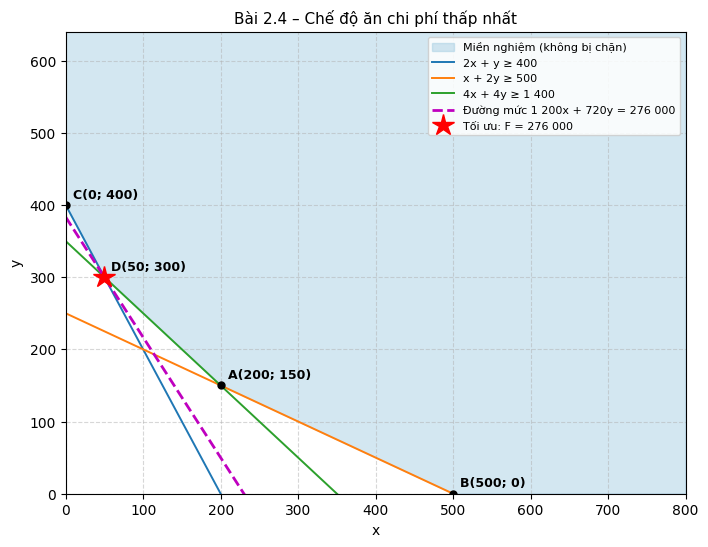

In [9]:
bt24 = giai("Bài 2.4 – Chế độ ăn chi phí thấp nhất", muc_tieu=(1200, 720), loai="min",
            rang_buoc=[(2, 1, ">=", 400),    # vitamin
                       (1, 2, ">=", 500),    # khoáng chất
                       (4, 4, ">=", 1400)],  # calo
            don_vi="đồng")

**Diễn giải kết quả.** Chế độ ăn tối ưu: **50 đơn vị $F_1$ và 300 đơn vị $F_2$**, chi phí **276 000 đồng/ngày**. Miền nghiệm **không bị chặn**; bài toán vẫn có giá trị nhỏ nhất vì chi phí tăng khi đi ra xa. *Lỗi thường gặp:* viết $4x + 4y \le 1400$ sẽ ra đáp số sai $(100;\,200)$ — điểm này **không** đủ calo ($4\cdot 100 + 4\cdot 200 = 1200 < 1400$).

<a name="b25"></a>

### Bài 2.5

> Một hãng bán gà rán nghiên cứu thấy rằng để làm ra món gà rán có chất lượng tốt nhất thì thức ăn cho gà cần được bổ sung 4 loại vitamin V1, V2, V3 và V4. Tổng lượng vitamin tối thiểu phải bổ sung cho mỗi 100 gam thức ăn cho gà là: V1 cần 50 đơn vị, V2 cần 100 đơn vị, V3 cần 60 đơn vị và V4 cần 180 đơn vị. Có hai loại thức ăn S1 và S2 cung cấp 4 loại vitamin này. Loại S1 có giá 720 đồng một gam và mỗi gam S1 có chứa 5 đơn vị V1, 25 đơn vị V2, 10 đơn vị V3 và 35 đơn vị V4. Loại S2 có giá 960 đồng một gam và mỗi gam S2 có chứa 25 đơn vị V1, 10 đơn vị V2, 10 đơn vị V3 và 20 đơn vị V4. Hỏi cần phải thêm vào 100 gam thức ăn cho gà mỗi loại S1 và S2 bao nhiêu gam để chi phí là thấp nhất mà vẫn đảm bảo dinh dưỡng cho gà?

**Lập mô hình.** Gọi $x, y$ (gam) là lượng S1, S2. V1: $5x + 25y \ge 50$; V2: $25x + 10y \ge 100$; V3: $10x + 10y \ge 60$; V4: $35x + 20y \ge 180$. $F = 720x + 960y$ (đồng) $\to \min$.

BÀI 2.5 – BỔ SUNG VITAMIN CHO THỨC ĂN GÀ
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị nhỏ nhất của  F = 720x + 960y   (đồng)
  với hệ ràng buộc:
      5x + 25y ≥ 50
      25x + 10y ≥ 100
      10x + 10y ≥ 60
      35x + 20y ≥ 180
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(4; 2)
  B(5; 1)
  C(10; 0)
  D(0; 10)
  E(4/3; 20/3)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm KHÔNG BỊ CHẶN (kéo dài ra vô tận), có các đỉnh A, B, C, D, E.
  F vẫn có giá trị nhỏ nhất: khi đường mức 720x + 960y = k dịch chuyển theo hướng làm F
  giảm, nó rời khỏi miền nghiệm tại một đỉnh  =>  chỉ cần so sánh F tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 720·4 + 960·2 = 4 800
  F(B) = 720·5 + 960·1 = 4 560
  F(C) = 720·10 + 960·0 = 7 200
  F(D) = 720·0 + 960·10 = 9 600
  F(E) = 720·4/3 + 960·20/3 = 7 360

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị nhỏ nhất bằng 4 560 tại đỉnh B: x = 5, y = 1.

KIỂM CHỨNG (scipy.optimize.linprog): F = 4 560  ->  KHỚP ✓

LỆ

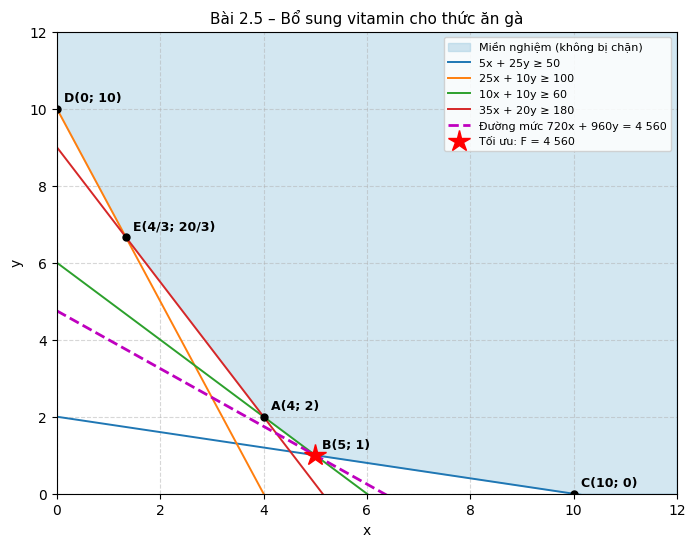

In [10]:
bt25 = giai("Bài 2.5 – Bổ sung vitamin cho thức ăn gà", muc_tieu=(720, 960), loai="min",
            rang_buoc=[(5, 25, ">=", 50),     # V1
                       (25, 10, ">=", 100),   # V2
                       (10, 10, ">=", 60),    # V3
                       (35, 20, ">=", 180)],  # V4
            don_vi="đồng", khung=(12, 12))

**Diễn giải kết quả.** Cần thêm **5 g S1 và 1 g S2** vào mỗi 100 g thức ăn, chi phí thấp nhất **4 560 đồng**. Bài có 4 ràng buộc nên vẽ tay dễ sai; đây là ví dụ tốt để thấy lợi ích của công cụ số trong việc xác định đúng các đỉnh.

<a name="thpt2025"></a>

## 4. Đề thi tốt nghiệp THPT năm 2025 (câu trả lời ngắn)

> Để gây quỹ từ thiện, câu lạc bộ thiện nguyện của một trường THPT tổ chức hoạt động bán hàng với hai mặt hàng là nước chanh và khoai chiên. Câu lạc bộ thiết kế hai thực đơn. Thực đơn 1 có giá 30 nghìn đồng, bao gồm hai cốc nước chanh và một túi khoai chiên. Thực đơn 2 có giá 50 nghìn đồng, bao gồm 3 cốc nước chanh và hai túi khoai chiên. Biết rằng câu lạc bộ chỉ làm được không quá 165 cốc nước chanh và 100 túi khoai chiên. Số tiền lớn nhất mà câu lạc bộ có thể nhận được sau khi bán hết hàng bằng bao nhiêu nghìn đồng?

**Lập mô hình.** Gọi $x, y$ là số suất thực đơn 1, thực đơn 2 (**nguyên**). Nước chanh: $2x + 3y \le 165$; khoai chiên: $x + 2y \le 100$. $F = 30x + 50y$ (nghìn đồng) $\to \max$.

ĐỀ TN THPT 2025 – BÁN NƯỚC CHANH VÀ KHOAI CHIÊN
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị lớn nhất của  F = 30x + 50y   (nghìn đồng)
  với hệ ràng buộc:
      2x + 3y ≤ 165
      x + 2y ≤ 100
      x ≥ 0,  y ≥ 0;  x, y nguyên

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(0; 0)
  B(82,5; 0)
  C(30; 35)
  D(0; 50)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCD (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 30·0 + 50·0 = 0
  F(B) = 30·82,5 + 50·0 = 2 475
  F(C) = 30·30 + 50·35 = 2 650
  F(D) = 30·0 + 50·50 = 2 500

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị lớn nhất bằng 2 650 tại đỉnh C: x = 30, y = 35.
  Phương án tối ưu đã là số nguyên  =>  thoả yêu cầu nghiệm nguyên.

KIỂM CHỨNG (scipy.optimize.linprog): F = 2 650  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):
   MienNghiem: 2*x + 3*y <= 165 && x + 2*y <= 100 && x >= 0 && y >= 0
 

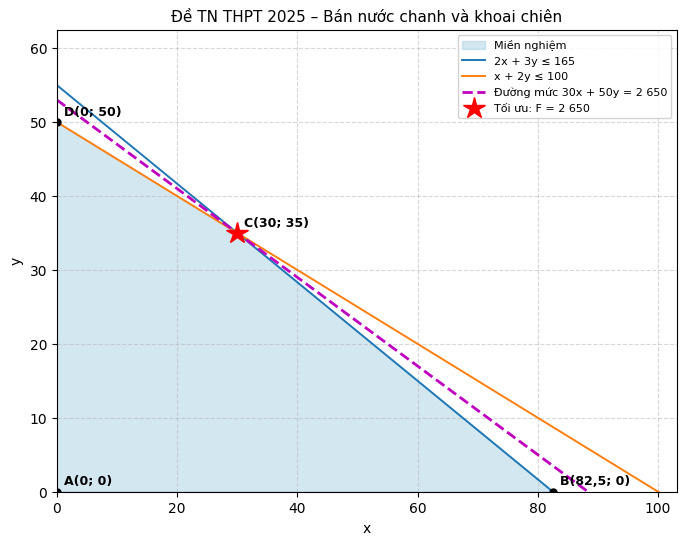

In [11]:
bt2025 = giai("Đề TN THPT 2025 – Bán nước chanh và khoai chiên", muc_tieu=(30, 50), loai="max",
              rang_buoc=[(2, 3, "<=", 165),   # nước chanh
                         (1, 2, "<=", 100)],  # khoai chiên
              so_nguyen=True, don_vi="nghìn đồng")

**Diễn giải kết quả.** Bán **30 suất thực đơn 1 và 35 suất thực đơn 2**, thu nhiều nhất **2 650 nghìn đồng** (đáp án điền: 2650).

<a name="mau"></a>

## 5. Mẫu — giải bài toán của bạn

Sửa dữ liệu rồi chạy ô dưới (nhớ đã chạy **Mục 1**). Mỗi ràng buộc viết dạng `(a, b, dấu, c)` nghĩa là $ax + by$ *dấu* $c$, với dấu là `"<="`, `">="` hoặc `"="`. Điều kiện $x, y \ge 0$ được thêm tự động.

| Tham số | Ý nghĩa |
|---|---|
| `muc_tieu=(p, q)` | $F = px + qy$ |
| `hang_so=c0` | cộng thêm hằng số vào $F$ (như Bài 2.15) |
| `loai="max"` / `"min"` | tìm giá trị lớn nhất / nhỏ nhất |
| `so_nguyen=True` | yêu cầu $x, y$ nguyên |
| `bien=("x", "y")` | tên biến khi in |
| `khung=(xmax, ymax)` | vùng vẽ hình |

BÀI CỦA TÔI
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị lớn nhất của  F = 3x + 2y
  với hệ ràng buộc:
      x + y ≤ 8
      x + 3y ≤ 18
      2x + y ≤ 14
      x ≥ 0,  y ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(0; 0)
  B(7; 0)
  C(6; 2)
  D(3; 5)
  E(0; 6)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm là đa giác ABCDE (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 3·0 + 2·0 = 0
  F(B) = 3·7 + 2·0 = 21
  F(C) = 3·6 + 2·2 = 22
  F(D) = 3·3 + 2·5 = 19
  F(E) = 3·0 + 2·6 = 12

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị lớn nhất bằng 22 tại đỉnh C: x = 6, y = 2.

KIỂM CHỨNG (scipy.optimize.linprog): F = 22  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):
   MienNghiem: x + y <= 8 && x + 3*y <= 18 && 2*x + y <= 14 && x >= 0 && y >= 0
   SetColor(MienNghiem, "#6BAED6")
   SetFilling(MienNghiem, 0.3)
   ShowLabel(MienNghiem, false)
   SetLineThickne

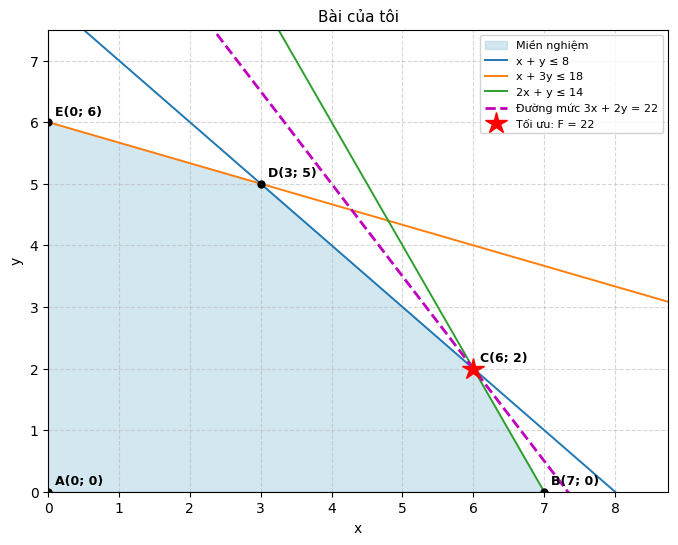

In [12]:
bt_cua_toi = giai("Bài của tôi", muc_tieu=(3, 2), loai="max",
                  rang_buoc=[(1, 1, "<=", 8),
                             (1, 3, "<=", 18),
                             (2, 1, "<=", 14)])
# tuong_tac(bt_cua_toi)   # bỏ dấu # để có thanh trượt đường mức

---
## 📝 Góp ý sau khi sử dụng

Cảm ơn bạn đã dùng thử học liệu! Xin dành khoảng **5 phút** điền **[Phiếu đánh giá mức độ đáp ứng của sản phẩm mô phỏng GeoGebra và Python](https://docs.google.com/forms/d/e/1FAIpQLScNqxvL5WIb8PxsOMvBbOrmmGTwV56bMyRV8-Nb_2Zvj225iw/viewform)** (không bắt buộc ghi họ tên). Ý kiến của bạn giúp nhóm hoàn thiện sản phẩm.

👉 **https://docs.google.com/forms/d/e/1FAIpQLScNqxvL5WIb8PxsOMvBbOrmmGTwV56bMyRV8-Nb_2Zvj225iw/viewform**

*Đề tài NCKH sinh viên TSV2026-211 – Trường Sư phạm, Đại học Cần Thơ · Kho học liệu: https://github.com/VuiPhamCTU/QHTT-GeoGebra-Python*